# EDA: GOODREADS BOOKS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carga de datos:
df = pd.read_csv("data/goodreads_best_books.csv")

In [7]:
# Primera exploración de la base de datos:
df.info()
df.head(10)
# Valores únicos de cada columna:
df.nunique()

<class 'pandas.DataFrame'>
RangeIndex: 52478 entries, 0 to 52477
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bookId            52478 non-null  str    
 1   title             52478 non-null  str    
 2   series            23470 non-null  str    
 3   author            52478 non-null  str    
 4   rating            52478 non-null  float64
 5   description       51140 non-null  str    
 6   language          48672 non-null  str    
 7   isbn              52478 non-null  str    
 8   genres            52478 non-null  str    
 9   characters        52478 non-null  str    
 10  bookFormat        51005 non-null  str    
 11  edition           4955 non-null   str    
 12  pages             50131 non-null  str    
 13  publisher         48782 non-null  str    
 14  publishDate       51598 non-null  str    
 15  firstPublishDate  31152 non-null  str    
 16  awards            52478 non-null  str    
 17  numR

bookId              52424
title               49927
series              22802
author              28227
rating                261
description         50888
language               81
isbn                48072
genres              44154
characters          12448
bookFormat            136
edition              1788
pages                1365
publisher           11110
publishDate         10635
firstPublishDate     8024
awards               9215
numRatings          19347
ratingsByStars      49908
likedPercent           66
setting              4651
coverImg            51819
bbeScore             3541
bbeVotes              649
price                3776
dtype: int64

In [8]:
# Eliminar las columnas que no me sirven para el análisis:
df = df.drop(columns=['bookId','description','isbn','characters','coverImg','setting'])

In [9]:
df.isnull().sum()

title                   0
series              29008
author                  0
rating                  0
language             3806
genres                  0
bookFormat           1473
edition             47523
pages                2347
publisher            3696
publishDate           880
firstPublishDate    21326
awards                  0
numRatings              0
ratingsByStars          0
likedPercent          622
bbeScore                0
bbeVotes                0
price               14365
dtype: int64

In [10]:
# Eliminar las columnas con muchos nulos:
df = df.drop(columns=['edition','firstPublishDate','price'])

In [11]:
df.isnull().sum()

title                 0
series            29008
author                0
rating                0
language           3806
genres                0
bookFormat         1473
pages              2347
publisher          3696
publishDate         880
awards                0
numRatings            0
ratingsByStars        0
likedPercent        622
bbeScore              0
bbeVotes              0
dtype: int64

In [12]:
# Tipos de datos:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52478 entries, 0 to 52477
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           52478 non-null  str    
 1   series          23470 non-null  str    
 2   author          52478 non-null  str    
 3   rating          52478 non-null  float64
 4   language        48672 non-null  str    
 5   genres          52478 non-null  str    
 6   bookFormat      51005 non-null  str    
 7   pages           50131 non-null  str    
 8   publisher       48782 non-null  str    
 9   publishDate     51598 non-null  str    
 10  awards          52478 non-null  str    
 11  numRatings      52478 non-null  int64  
 12  ratingsByStars  52478 non-null  str    
 13  likedPercent    51856 non-null  float64
 14  bbeScore        52478 non-null  int64  
 15  bbeVotes        52478 non-null  int64  
dtypes: float64(2), int64(3), str(11)
memory usage: 6.4 MB


In [13]:
# Cambiar el tipo de dato de la columna 'pages' a numérico:
df['pages'] = pd.to_numeric(df['pages'], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52478 entries, 0 to 52477
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           52478 non-null  str    
 1   series          23470 non-null  str    
 2   author          52478 non-null  str    
 3   rating          52478 non-null  float64
 4   language        48672 non-null  str    
 5   genres          52478 non-null  str    
 6   bookFormat      51005 non-null  str    
 7   pages           50108 non-null  float64
 8   publisher       48782 non-null  str    
 9   publishDate     51598 non-null  str    
 10  awards          52478 non-null  str    
 11  numRatings      52478 non-null  int64  
 12  ratingsByStars  52478 non-null  str    
 13  likedPercent    51856 non-null  float64
 14  bbeScore        52478 non-null  int64  
 15  bbeVotes        52478 non-null  int64  
dtypes: float64(3), int64(3), str(10)
memory usage: 6.4 MB


In [14]:
df.head(15)

,title,series,author,rating,language,genres,bookFormat,pages,publisher,publishDate,awards,numRatings,ratingsByStars,likedPercent,bbeScore,bbeVotes
0,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,English,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...",Hardcover,374.0,Scholastic Press,09/14/08,['Locus Award Nominee for Best Young Adult Boo...,6376780,"['3444695', '1921313', '745221', '171994', '93...",96.0,2993816,30516
1,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPré (Illustrator)",4.50,English,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",Paperback,870.0,Scholastic Inc.,09/28/04,['Bram Stoker Award for Works for Young Reader...,2507623,"['1593642', '637516', '222366', '39573', '14526']",98.0,2632233,26923
2,To Kill a Mockingbird,To Kill a Mockingbird,Harper Lee,4.28,English,"['Classics', 'Fiction', 'Historical Fiction', ...",Paperback,324.0,Harper Perennial Modern Classics,05/23/06,"['Pulitzer Prize for Fiction (1961)', 'Audie A...",4501075,"['2363896', '1333153', '573280', '149952', '80...",95.0,2269402,23328
3,Pride and Prejudice,NaN,"Jane Austen, Anna Quindlen (Introduction)",4.26,English,"['Classics', 'Fiction', 'Romance', 'Historical...",Paperback,279.0,Modern Library,10/10/00,[],2998241,"['1617567', '816659', '373311', '113934', '767...",94.0,1983116,20452
4,Twilight,The Twilight Saga #1,Stephenie Meyer,3.60,English,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...",Paperback,501.0,"Little, Brown and Company",09/06/06,"['Georgia Peach Book Award (2007)', 'Buxtehude...",4964519,"['1751460', '1113682', '1008686', '542017', '5...",78.0,1459448,14874
5,The Book Thief,NaN,Markus Zusak (Goodreads Author),4.37,English,"['Historical Fiction', 'Fiction', 'Young Adult...",Hardcover,552.0,Alfred A. Knopf,03/14/06,['National Jewish Book Award for Children’s an...,1834276,"['1048230', '524674', '186297', '48864', '26211']",96.0,1372809,14168
6,Animal Farm,NaN,"George Orwell, Russell Baker (Preface), C.M. W...",3.95,English,"['Classics', 'Fiction', 'Dystopia', 'Fantasy',...",Mass Market Paperback,141.0,Signet Classics,04/28/96,"['Prometheus Hall of Fame Award (2011)', 'Retr...",2740713,"['986764', '958699', '545475', '165093', '84682']",91.0,1276599,13264
7,The Chronicles of Narnia,The Chronicles of Narnia (Publication Order) #1–7,"C.S. Lewis, Pauline Baynes (Illustrator)",4.26,English,"['Fantasy', 'Classics', 'Fiction', 'Young Adul...",Paperback,767.0,HarperCollins,09/16/02,[],517740,"['254964', '167572', '74362', '15423', '5419']",96.0,1238556,12949
8,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,The Lord of the Rings #0-3,J.R.R. Tolkien,4.60,English,"['Fantasy', 'Fiction', 'Classics', 'Adventure'...",Mass Market Paperback,1728.0,Ballantine Books,09/25/12,[],110146,"['78217', '22857', '6628', '1477', '967']",98.0,1159802,12111
9,Gone with the Wind,NaN,Margaret Mitchell,4.30,English,"['Classics', 'Historical Fiction', 'Fiction', ...",Mass Market Paperback,1037.0,Warner Books,04/01/99,"['Pulitzer Prize for Novel (1937)', 'National ...",1074620,"['602138', '275517', '133535', '39008', '24422']",94.0,1087732,11211


In [15]:
# Busqueda de valores unicos en las columnas tipo string:
print(df['bookFormat'].unique().tolist())

['Hardcover', 'Paperback', 'Mass Market Paperback', 'Kindle Edition', 'Audiobook', 'ebook', nan, 'Board book', 'Boxed Set', 'Leather Bound', 'Capa dura', 'Trade Paperback', 'Box Set', 'Board Book', 'Nook', 'Library Binding', 'Capa comum', 'Pasta blanda', 'Audio Cassette', 'Unknown Binding', 'Audio CD', 'Slipcased Hardcover', 'Broschiert', 'Paperback ', 'Brochura', 'MP3 CD', 'Audible Audio', 'hardcover', 'cloth', 'Pasta dura', 'Paperback/Kindle', 'paper', 'Hard Cover', 'Perfect Paperback', 'Poche', 'Comics', 'Hardcover Slipcased ', 'Unbound', 'Taschenbuch', 'Paper back', 'Paperback, Kindle, Ebook, Audio', 'CD-ROM', 'Paperback and Kindle', 'Hardcover im Schuber', 'paperback', 'Graphic Novels', 'Broché', 'Science Fiction Book Club Omnibus', 'Newsprint', 'Spiral-bound', 'Mass Market', 'Hardcover Boxed Set', 'Mass Market Paperback ', 'Hardback', 'Audio', 'Novel', 'Gebundene Ausgabe', 'softcover', 'گالینگور-وزیری', 'hardbound', 'Hard cover, Soft cover, e-book', 'Kindle', 'Paperback/Ebook', '

In [16]:
# Ver todos los valores únicos y su frecuencia
print(df['bookFormat'].value_counts().tolist())


[26773, 12268, 5834, 2567, 2547, 145, 138, 106, 100, 53, 35, 35, 33, 31, 20, 20, 17, 17, 16, 10, 10, 8, 8, 7, 7, 7, 7, 7, 6, 6, 5, 5, 5, 5, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [17]:
counts = df['bookFormat'].value_counts()
total = len(df)

for fmt, count in counts.items():
    pct = (count / total) * 100
    print(f"{fmt}: {count} ({pct:.1f}%)")

Paperback: 26773 (51.0%)
Hardcover: 12268 (23.4%)
Kindle Edition: 5834 (11.1%)
Mass Market Paperback: 2567 (4.9%)
ebook: 2547 (4.9%)
Audio CD: 145 (0.3%)
Nook: 138 (0.3%)
Audiobook: 106 (0.2%)
Unknown Binding: 100 (0.2%)
Trade Paperback: 53 (0.1%)
Library Binding: 35 (0.1%)
Audio Cassette: 35 (0.1%)
Audible Audio: 33 (0.1%)
paperback: 31 (0.1%)
Leather Bound: 20 (0.0%)
Board Book: 20 (0.0%)
Board book: 17 (0.0%)
Comics: 17 (0.0%)
Audio: 16 (0.0%)
Boxed Set: 10 (0.0%)
hardcover: 10 (0.0%)
Broché: 8 (0.0%)
Mass Market: 8 (0.0%)
paper: 7 (0.0%)
Perfect Paperback: 7 (0.0%)
Taschenbuch: 7 (0.0%)
Graphic Novels: 7 (0.0%)
Hardback: 7 (0.0%)
Capa dura: 6 (0.0%)
Online: 6 (0.0%)
Slipcased Hardcover: 5 (0.0%)
MP3 CD: 5 (0.0%)
cloth: 5 (0.0%)
Spiral-bound: 5 (0.0%)
Capa comum: 4 (0.0%)
Pasta dura: 4 (0.0%)
Poche: 4 (0.0%)
Klappenbroschur: 4 (0.0%)
Box Set: 3 (0.0%)
Pasta blanda: 3 (0.0%)
Broschiert: 3 (0.0%)
Paperback : 3 (0.0%)
Unbound: 3 (0.0%)
eBook Kindle: 3 (0.0%)
Wattpad: 3 (0.0%)
mass_mark

In [18]:
# Quitar formatos que no son válidos para el análisis, como audiolibros, libros de texto, etc.:
formatos_validos = [
    'Paperback',
    'Hardcover',
    'Kindle Edition',
    'Mass Market Paperback',
    'ebook'
]

df = df[df['bookFormat'].isin(formatos_validos)]
print(f"Filas restantes: {len(df)}")
print(df['bookFormat'].value_counts())

Filas restantes: 49989
bookFormat
Paperback                26773
Hardcover                12268
Kindle Edition            5834
Mass Market Paperback     2567
ebook                     2547
Name: count, dtype: int64


In [19]:
print(df.series.unique())

<StringArray>
[                              'The Hunger Games #1',
                                   'Harry Potter #5',
                             'To Kill a Mockingbird',
                                                 nan,
                              'The Twilight Saga #1',
 'The Chronicles of Narnia (Publication Order) #1–7',
                        'The Lord of the Rings #0-3',
           'The Hitchhiker's Guide to the Galaxy #1',
                                 'Robert Langdon #2',
             'Alice's Adventures in Wonderland #1-2',
 ...
                                'Sweet Addiction #2',
                      'Le Cycle de l'invisible #1-3',
                         'Theodosia Throckmorton #4',
                       'Treasure Hunter Security #8',
                                     'Fated Mate #1',
                                 'Soul Guardians #2',
                                      'Port Fare #2',
                                 'Sense of Truth #2',
         

In [20]:
# 1. Ver ejemplos reales del contenido
print(df['series'].dropna().head(30))

# 2. Verificar si realmente hay '#' en los valores
print(df['series'].str.contains('#', regex=False, na=False).sum())

# 3. Ver el tipo de dato
print(df['series'].dtype)

0                                   The Hunger Games #1
1                                       Harry Potter #5
2                                 To Kill a Mockingbird
4                                  The Twilight Saga #1
7     The Chronicles of Narnia (Publication Order) #1–7
8                            The Lord of the Rings #0-3
11              The Hitchhiker's Guide to the Galaxy #1
14                                    Robert Langdon #2
17                Alice's Adventures in Wonderland #1-2
21                                         Divergent #1
28                            The Mortal Instruments #1
31                              Anne of Green Gables #1
32                                      Harry Potter #1
37                                           Dracula #1
42                   Percy Jackson and the Olympians #1
45                                      Time Quintet #1
46                            A Song of Ice and Fire #1
47                        Adventures of Tom and 

In [21]:
import re

# Patrón que cubre ambos guiones: - (ASCII) y – (Unicode en dash)
patron_rango = r'#\d+[-–]\d+'

# Verificar que ahora pilla Narnia
test = df[df['series'].str.contains(patron_rango, regex=True, na=False)]
print(test[['title', 'series']].head(10))

# Aplicar el filtro
df = df[~df['series'].str.contains(patron_rango, regex=True, na=False)]
print(f"Dataset final: {len(df)}")

                                                 title  \
7                             The Chronicles of Narnia   
8    J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...   
17   Alice's Adventures in Wonderland & Through the...   
85                              The Brothers Karamazov   
140                                           Watchmen   
144                                  The Divine Comedy   
184                    The Hunger Games Trilogy Boxset   
204                                 His Dark Materials   
244                         The Wind-Up Bird Chronicle   
246                                     The Green Mile   

                                                series  
7    The Chronicles of Narnia (Publication Order) #1–7  
8                           The Lord of the Rings #0-3  
17               Alice's Adventures in Wonderland #1-2  
85                         The Brothers Karamazov #1-4  
140                                     Watchmen #1-12  
144                

In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 49036 entries, 0 to 52477
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           49036 non-null  str    
 1   series          21584 non-null  str    
 2   author          49036 non-null  str    
 3   rating          49036 non-null  float64
 4   language        45956 non-null  str    
 5   genres          49036 non-null  str    
 6   bookFormat      49036 non-null  str    
 7   pages           47528 non-null  float64
 8   publisher       46309 non-null  str    
 9   publishDate     48651 non-null  str    
 10  awards          49036 non-null  str    
 11  numRatings      49036 non-null  int64  
 12  ratingsByStars  49036 non-null  str    
 13  likedPercent    48494 non-null  float64
 14  bbeScore        49036 non-null  int64  
 15  bbeVotes        49036 non-null  int64  
dtypes: float64(3), int64(3), str(10)
memory usage: 6.4 MB


In [23]:
df.head(20)

,title,series,author,rating,language,genres,bookFormat,pages,publisher,publishDate,awards,numRatings,ratingsByStars,likedPercent,bbeScore,bbeVotes
0,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,English,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...",Hardcover,374.0,Scholastic Press,09/14/08,['Locus Award Nominee for Best Young Adult Boo...,6376780,"['3444695', '1921313', '745221', '171994', '93...",96.0,2993816,30516
1,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPré (Illustrator)",4.50,English,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",Paperback,870.0,Scholastic Inc.,09/28/04,['Bram Stoker Award for Works for Young Reader...,2507623,"['1593642', '637516', '222366', '39573', '14526']",98.0,2632233,26923
2,To Kill a Mockingbird,To Kill a Mockingbird,Harper Lee,4.28,English,"['Classics', 'Fiction', 'Historical Fiction', ...",Paperback,324.0,Harper Perennial Modern Classics,05/23/06,"['Pulitzer Prize for Fiction (1961)', 'Audie A...",4501075,"['2363896', '1333153', '573280', '149952', '80...",95.0,2269402,23328
3,Pride and Prejudice,NaN,"Jane Austen, Anna Quindlen (Introduction)",4.26,English,"['Classics', 'Fiction', 'Romance', 'Historical...",Paperback,279.0,Modern Library,10/10/00,[],2998241,"['1617567', '816659', '373311', '113934', '767...",94.0,1983116,20452
4,Twilight,The Twilight Saga #1,Stephenie Meyer,3.60,English,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...",Paperback,501.0,"Little, Brown and Company",09/06/06,"['Georgia Peach Book Award (2007)', 'Buxtehude...",4964519,"['1751460', '1113682', '1008686', '542017', '5...",78.0,1459448,14874
5,The Book Thief,NaN,Markus Zusak (Goodreads Author),4.37,English,"['Historical Fiction', 'Fiction', 'Young Adult...",Hardcover,552.0,Alfred A. Knopf,03/14/06,['National Jewish Book Award for Children’s an...,1834276,"['1048230', '524674', '186297', '48864', '26211']",96.0,1372809,14168
6,Animal Farm,NaN,"George Orwell, Russell Baker (Preface), C.M. W...",3.95,English,"['Classics', 'Fiction', 'Dystopia', 'Fantasy',...",Mass Market Paperback,141.0,Signet Classics,04/28/96,"['Prometheus Hall of Fame Award (2011)', 'Retr...",2740713,"['986764', '958699', '545475', '165093', '84682']",91.0,1276599,13264
9,Gone with the Wind,NaN,Margaret Mitchell,4.30,English,"['Classics', 'Historical Fiction', 'Fiction', ...",Mass Market Paperback,1037.0,Warner Books,04/01/99,"['Pulitzer Prize for Novel (1937)', 'National ...",1074620,"['602138', '275517', '133535', '39008', '24422']",94.0,1087732,11211
10,The Fault in Our Stars,NaN,John Green (Goodreads Author),4.21,English,"['Young Adult', 'Romance', 'Fiction', 'Contemp...",Hardcover,313.0,Dutton Books,01/10/12,"['Georgia Peach Book Award (2013)', 'Buxtehude...",3550714,"['1784471', '1022406', '512574', '150365', '80...",93.0,1087056,11287
11,The Hitchhiker's Guide to the Galaxy,The Hitchhiker's Guide to the Galaxy #1,Douglas Adams,4.22,English,"['Science Fiction', 'Fiction', 'Humor', 'Fanta...",Paperback,193.0,Del Rey,06/23/07,[],1436325,"['725771', '420864', '199846', '58326', '31518']",94.0,1063601,10996


In [24]:
# Crear columna is_series
df['is_series'] = df['series'].str.contains('#', regex=False, na=False)

# Verificar resultado
print(df['is_series'].value_counts())
print(df[['title', 'series', 'is_series']].head(10))

is_series
False    28398
True     20638
Name: count, dtype: int64
                                        title  \
0                            The Hunger Games   
1   Harry Potter and the Order of the Phoenix   
2                       To Kill a Mockingbird   
3                         Pride and Prejudice   
4                                    Twilight   
5                              The Book Thief   
6                                 Animal Farm   
9                          Gone with the Wind   
10                     The Fault in Our Stars   
11       The Hitchhiker's Guide to the Galaxy   

                                     series  is_series  
0                       The Hunger Games #1       True  
1                           Harry Potter #5       True  
2                     To Kill a Mockingbird      False  
3                                       NaN      False  
4                      The Twilight Saga #1       True  
5                                       NaN      Fal

In [25]:
# Extraer todos los valores entre paréntesis de toda la columna
roles = (
    df['author']
    .dropna()
    .str.findall(r'\(([^)]+)\)')  # extrae todo lo que hay entre ( )
    .explode()                     # desanida las listas
    .str.strip()                   # elimina espacios
    .value_counts()                # cuenta frecuencias
)

print(roles.to_string())

author
Goodreads Author                    23001
Translator                           2731
Illustrator                          2128
Editor                               1180
Introduction                          707
Contributor                           649
Illustrations                         305
Foreword                              263
Translation                           133
Artist                                125
Writer                                117
translator                            114
Foreword by                            97
Creator                                87
Afterword                              80
Narrator                               77
pseudonym                              59
Pseudonym                              54
ترجمة                                  44
Photographer                           42
Preface                                40
illustrator                            39
Adapter                                33
Colorist                   

In [26]:
def limpiar_autores(texto):
    if not isinstance(texto, str):
        return texto
    
    roles_no_autor = {
        'illustrator', 'translator', 'editor', 'introduction', 'contributor',
        'illustrations', 'foreword', 'translation', 'artist', 'narrator',
        'pseudonym', 'photographer', 'preface', 'colorist', 'letterer',
        'adapter', 'compiler', 'designer', 'inker', 'penciller', 
        'afterword', 'cover artist', 'ghostwriter'
    }
    
    autores = []
    for parte in texto.split(','):
        parte = parte.strip()
        rol = ''
        match = re.search(r'\(([^)]+)\)', parte)
        if match:
            rol = match.group(1).lower().strip()
        
        # Siempre limpiar el paréntesis del nombre
        nombre = re.sub(r'\s*\([^)]*\)', '', parte).strip()
        
        if nombre and rol not in roles_no_autor:
            autores.append(nombre)
    
    return ', '.join(autores) if autores else None

df['main_author'] = df['author'].apply(limpiar_autores)
print(df[['author', 'main_author']].head(15))

                                               author  \
0                                     Suzanne Collins   
1           J.K. Rowling, Mary GrandPré (Illustrator)   
2                                          Harper Lee   
3           Jane Austen, Anna Quindlen (Introduction)   
4                                     Stephenie Meyer   
5                     Markus Zusak (Goodreads Author)   
6   George Orwell, Russell Baker (Preface), C.M. W...   
9                                   Margaret Mitchell   
10                      John Green (Goodreads Author)   
11                                      Douglas Adams   
12                                   Shel Silverstein   
13  Emily Brontë, Richard J. Dunn (Editor), David ...   
14                       Dan Brown (Goodreads Author)   
15                                      Arthur Golden   
16      Oscar Wilde, Jeffrey Eugenides (Introduction)   

                       main_author  
0                  Suzanne Collins  
1            

In [27]:
df.info()

<class 'pandas.DataFrame'>
Index: 49036 entries, 0 to 52477
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           49036 non-null  str    
 1   series          21584 non-null  str    
 2   author          49036 non-null  str    
 3   rating          49036 non-null  float64
 4   language        45956 non-null  str    
 5   genres          49036 non-null  str    
 6   bookFormat      49036 non-null  str    
 7   pages           47528 non-null  float64
 8   publisher       46309 non-null  str    
 9   publishDate     48651 non-null  str    
 10  awards          49036 non-null  str    
 11  numRatings      49036 non-null  int64  
 12  ratingsByStars  49036 non-null  str    
 13  likedPercent    48494 non-null  float64
 14  bbeScore        49036 non-null  int64  
 15  bbeVotes        49036 non-null  int64  
 16  is_series       49036 non-null  bool   
 17  main_author     48864 non-null  str    
dtypes:

In [28]:
df[df['main_author'].isna()]

,title,series,author,rating,language,genres,bookFormat,pages,publisher,publishDate,awards,numRatings,ratingsByStars,likedPercent,bbeScore,bbeVotes,is_series,main_author
683,The Book of Mormon: Another Testament of Jesus...,NaN,Joseph Smith Jr. (Translator),4.34,English,"['Religion', 'Nonfiction', 'Lds', 'Church', 'S...",Paperback,531.0,The Church of Jesus Christ of Latter-day Saints,10/28/13,[],75222,"['58923', '2290', '2811', '2934', '8264']",85.0,11029,121,False,NaN
4215,Mahabharata,NaN,C. Rajagopalachari (Translator),4.28,English,"['Classics', 'Mythology', 'Religion', 'Fiction...",Paperback,483.0,Bharatiya Vidya Bhavan,1951,[],7469,"['3871', '2289', '973', '235', '101']",96.0,737,10,False,NaN
5799,The Law,NaN,Frédéric Bastiat (Contributor),4.38,English,"['Politics', 'Philosophy', 'Economics', 'Nonfi...",Paperback,61.0,Ludwig von Mises Institute,June 30th 2011,[],10521,"['6155', '2756', '1180', '307', '123']",96.0,488,6,False,NaN
6518,Chicken Soup for the Soul,NaN,"Jack Canfield (Editor), Mark Victor Hansen (Ed...",3.96,English,"['Nonfiction', 'Self Help', 'Inspirational', '...",Paperback,428.0,HCI,July 1st 2001,[],36089,"['13811', '11212', '7928', '2183', '955']",91.0,417,5,False,NaN
8437,Autobiography,NaN,Morrissey (Artist),3.62,English,"['Music', 'Nonfiction', 'Biography', 'Memoir',...",Paperback,457.0,Penguin Books,October 17th 2013,[],10994,"['2756', '3577', '3000', '1090', '571']",85.0,296,3,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50979,"Multiculturalism, Postcoloniality, and Transna...",NaN,Ella Shohat (Editor),4.06,English,[],Paperback,350.0,Rutgers University Press,March 4th 2003,[],16,"['4', '9', '3', '0', '0']",100.0,26,1,False,NaN
51475,The Practice of Poetry: Writing Exercises From...,NaN,"Robin Behn (Editor), Chase Twichell (Editor)",4.05,English,"['Poetry', 'Writing', 'Nonfiction', 'Reference...",Paperback,320.0,William Morrow Paperbacks,September 23rd 1992,[],1177,"['429', '437', '257', '44', '10']",95.0,19,2,False,NaN
52154,The Compact Edition of the Oxford English Dict...,NaN,"Herbert Coleridge (editor), Frederick J. Furni...",4.62,English,"['Reference', 'Language', 'Nonfiction', 'Educa...",Hardcover,2.0,Clarendon/Oxford University Press (Oxford),October 15th 1971,[],218,"['177', '18', '11', '5', '7']",94.0,7,1,False,NaN
52194,"Jesus, Skepticism, and the Problem of History:...",NaN,"Darrell L. Bock (Editor), J. Ed Komoszewski (E...",4.25,NaN,"['New Testament', 'Christian']",Paperback,384.0,Zondervan Academic,October 8th 2019,[],12,"['5', '5', '2', '0', '0']",100.0,7,1,False,NaN


In [29]:
df = df.dropna(subset=['main_author'])


In [30]:
# Análisis estadístico de las variables numéricas:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rating,48864.0,4.015282,0.358845,0.0,3.82,4.02,4.22,5.0
pages,47362.0,320.820426,207.780579,0.0,213.00,304.00,388.00,11095.0
numRatings,48864.0,18650.932527,107306.049301,0.0,371.00,2472.50,9859.25,7048471.0
likedPercent,48330.0,92.181875,5.914926,0.0,90.00,93.00,96.00,100.0
bbeScore,48864.0,2001.870395,35205.939954,0.0,84.00,97.00,189.00,2993816.0
bbeVotes,48864.0,22.765042,369.673606,-4.0,1.00,1.00,2.00,30516.0


In [31]:
# Análisis estadístico de todas las variables:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,48864,46500,Legacy,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
series,21561,20961,Star Wars Legends,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
author,48864,26581,Agatha Christie,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,48864.0,NaN,NaN,NaN,4.015282,0.358845,0.0,3.82,4.02,4.22,5.0
language,45799,75,English,40510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genres,48864,41504,[],4076,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bookFormat,48864,5,Paperback,26133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pages,47362.0,NaN,NaN,NaN,320.820426,207.780579,0.0,213.0,304.0,388.0,11095.0
publisher,46140,10428,Vintage,563,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publishDate,48479,10159,Published,479,NaN,NaN,NaN,NaN,NaN,NaN,NaN


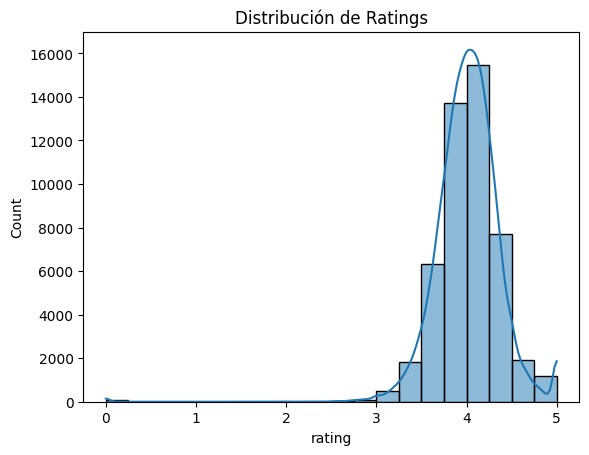

In [32]:
sns.histplot(df['rating'], bins=20, kde=True)
plt.title("Distribución de Ratings")
plt.show()

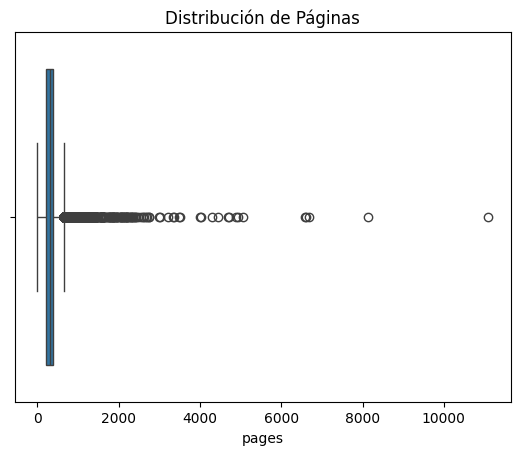

In [33]:
sns.boxplot(x=df['pages'])
plt.title("Distribución de Páginas")
plt.show()

In [34]:
print(df[df['pages'] > 1500][['title', 'pages']].sort_values('pages', ascending=False).head(20))
# Se tratan de boxsets de enciclopedias, diccionarios, etc. No son libros normales, por lo que se hará un subset de libros con menos de 5000 páginas para el análisis:
df_individual = df[df['pages'] <= 1500]
df_individual

                                                   title    pages
22960                         The Complete Wheel of Time  11095.0
20098                                          Homestuck   8124.0
3148                                                Worm   6680.0
23326                                سه تفنگدار: ١٠ جلدی   6600.0
4692      The Complete Aubrey/Maturin Novels (5 Volumes)   6576.0
38814  One Piece Box Set 3: Thriller Bark to New Worl...   5056.0
38247  One Piece Box Set 2: Skypeia and Water Seven: ...   4936.0
29873                                   Capital D: Adult   4892.0
37618  One Piece Box Set: East Blue and Baroque Works...   4720.0
24412                                  سير أعلام النبلاء   4683.0
10377                     Black Dagger Brotherhood, #1-9   4440.0
40130             Encyclopedia of Philosophy, 4 Vol. Set   4300.0
18940                                Chatur Veda Samhita   4032.0
21885                                     في ظلال القرآن   4012.0
28463     

,title,series,author,rating,language,genres,bookFormat,pages,publisher,publishDate,awards,numRatings,ratingsByStars,likedPercent,bbeScore,bbeVotes,is_series,main_author
0,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,English,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...",Hardcover,374.0,Scholastic Press,09/14/08,['Locus Award Nominee for Best Young Adult Boo...,6376780,"['3444695', '1921313', '745221', '171994', '93...",96.0,2993816,30516,True,Suzanne Collins
1,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPré (Illustrator)",4.50,English,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",Paperback,870.0,Scholastic Inc.,09/28/04,['Bram Stoker Award for Works for Young Reader...,2507623,"['1593642', '637516', '222366', '39573', '14526']",98.0,2632233,26923,True,J.K. Rowling
2,To Kill a Mockingbird,To Kill a Mockingbird,Harper Lee,4.28,English,"['Classics', 'Fiction', 'Historical Fiction', ...",Paperback,324.0,Harper Perennial Modern Classics,05/23/06,"['Pulitzer Prize for Fiction (1961)', 'Audie A...",4501075,"['2363896', '1333153', '573280', '149952', '80...",95.0,2269402,23328,False,Harper Lee
3,Pride and Prejudice,NaN,"Jane Austen, Anna Quindlen (Introduction)",4.26,English,"['Classics', 'Fiction', 'Romance', 'Historical...",Paperback,279.0,Modern Library,10/10/00,[],2998241,"['1617567', '816659', '373311', '113934', '767...",94.0,1983116,20452,False,Jane Austen
4,Twilight,The Twilight Saga #1,Stephenie Meyer,3.60,English,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...",Paperback,501.0,"Little, Brown and Company",09/06/06,"['Georgia Peach Book Award (2007)', 'Buxtehude...",4964519,"['1751460', '1113682', '1008686', '542017', '5...",78.0,1459448,14874,True,Stephenie Meyer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52472,Unbelievable,Port Fare #2,Sherry Gammon (Goodreads Author),4.16,English,"['Romance', 'Young Adult', 'Contemporary', 'Co...",Paperback,360.0,Wordpaintings Unlimited,April 11th 2013,[],1028,"['442', '384', '142', '48', '12']",94.0,0,1,True,Sherry Gammon
52474,Anasazi,Sense of Truth #2,Emma Michaels,4.19,English,"['Mystery', 'Young Adult']",Paperback,190.0,Bokheim Publishing,August 5th 2011,[],37,"['16', '14', '5', '2', '0']",95.0,0,1,True,Emma Michaels
52475,Marked,Soul Guardians #1,Kim Richardson (Goodreads Author),3.70,English,"['Fantasy', 'Young Adult', 'Paranormal', 'Ange...",Paperback,280.0,CreateSpace,March 18th 2011,"[""Readers' Favorite Book Award (2011)""]",6674,"['2109', '1868', '1660', '647', '390']",84.0,0,1,True,Kim Richardson
52476,Wayward Son,NaN,"Tom Pollack (Goodreads Author), John Loftus (G...",3.85,English,"['Fiction', 'Mystery', 'Historical Fiction', '...",Paperback,507.0,Cascada Productions,September 1st 2011,[],238,"['77', '78', '59', '19', '5']",90.0,0,1,False,"Tom Pollack, John Loftus, Jim Alves"


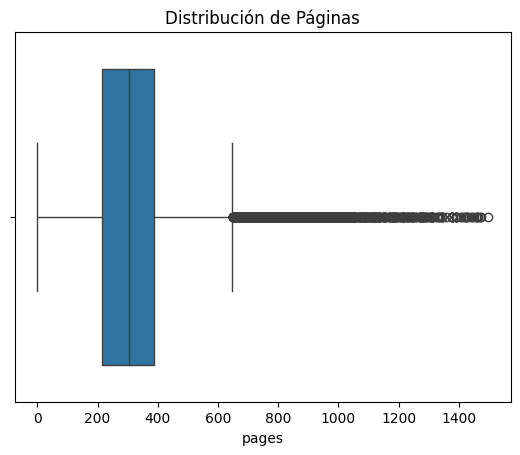

In [35]:
sns.boxplot(x=df_individual['pages'])
plt.title("Distribución de Páginas")
plt.show()

In [36]:
print(df_individual[df_individual['pages'] > 1500][['title', 'pages']].sort_values('pages', ascending=False).head(20))

Empty DataFrame
Columns: [title, pages]
Index: []


In [37]:
print(df_individual['numRatings'].describe())

count    4.725600e+04
mean     1.924139e+04
std      1.090606e+05
min      0.000000e+00
25%      4.297500e+02
50%      2.659000e+03
75%      1.033400e+04
max      7.048471e+06
Name: numRatings, dtype: float64


In [38]:
print((df_individual['rating'] == 0).sum())

40


In [39]:
MINIMO_RATINGS = 50  # ajusta según lo que veas

df_individual = df_individual[df_individual['numRatings'] >= MINIMO_RATINGS]

# También eliminar rating == 0 (sin puntuación real)
df_individual = df_individual[df_individual['rating'] > 0]

In [40]:
df_individual[df_individual['rating'] == 5.0][['title', 'rating', 'numRatings', 'ratingsByStars']].head(10)

,title,rating,numRatings,ratingsByStars


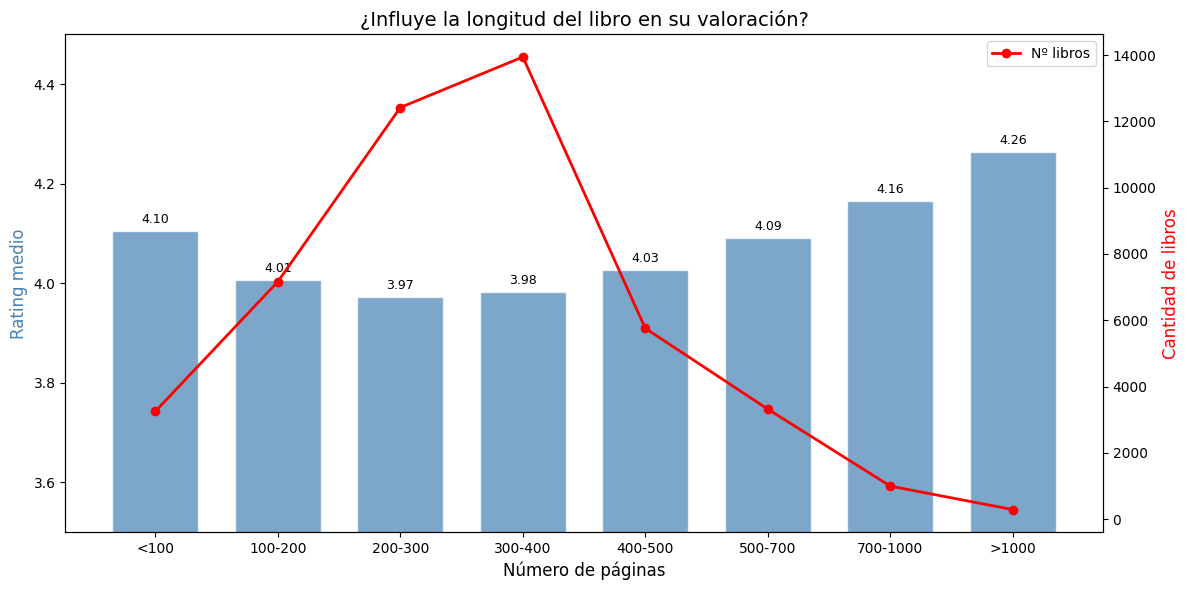

In [41]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = df[df['pages'].between(10, 1500)].copy()

bins = [0, 100, 200, 300, 400, 500, 700, 1000, 1500]
labels = ['<100', '100-200', '200-300', '300-400', 
          '400-500', '500-700', '700-1000', '>1000']

df_plot['rango_paginas'] = pd.cut(df_plot['pages'], bins=bins, labels=labels)

rating_por_rango = df_plot.groupby('rango_paginas', observed=True)['rating'].mean()
cantidad_por_rango = df_plot.groupby('rango_paginas', observed=True)['rating'].count()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras: rating medio (eje izquierdo)
bars = ax1.bar(rating_por_rango.index, rating_por_rango.values,
               color='steelblue', alpha=0.7, edgecolor='white', width=0.7)
ax1.set_ylabel('Rating medio', fontsize=12, color='steelblue')
ax1.set_ylim(3.5, 4.5)

for bar, val in zip(bars, rating_por_rango.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# Línea: cantidad de libros (eje derecho)
ax2 = ax1.twinx()
ax2.plot(cantidad_por_rango.index, cantidad_por_rango.values,
         color='red', marker='o', linewidth=2, label='Nº libros')
ax2.set_ylabel('Cantidad de libros', fontsize=12, color='red')

ax1.set_xlabel('Número de páginas', fontsize=12)
plt.title('¿Influye la longitud del libro en su valoración?', fontsize=14)
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

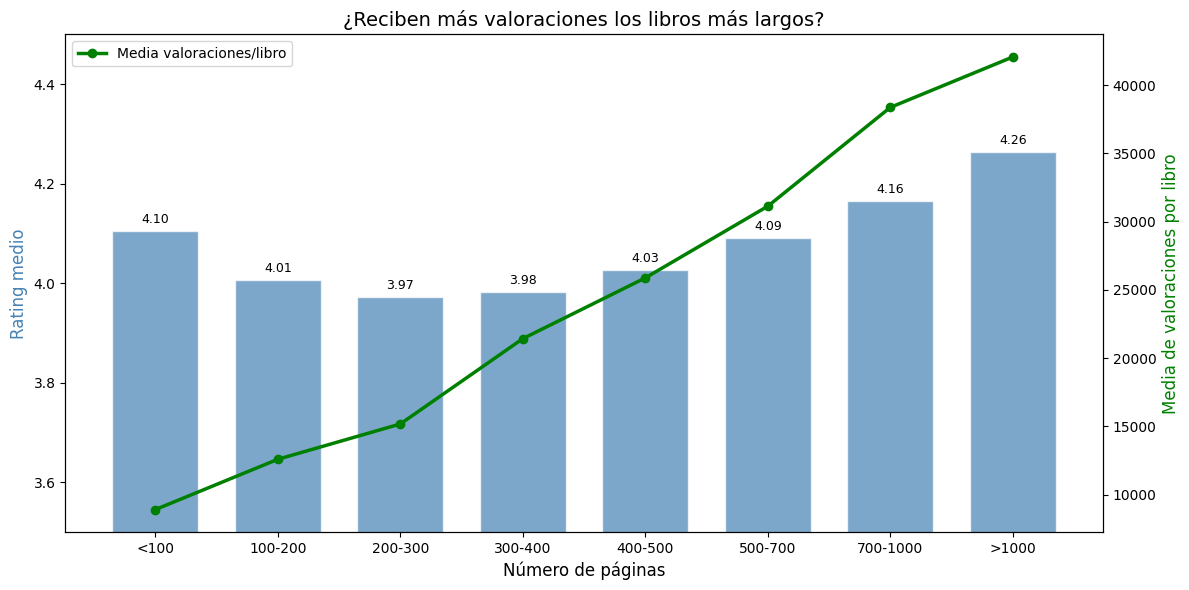

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

df_plot = df[df['pages'].between(10, 1500)].copy()

bins = [0, 100, 200, 300, 400, 500, 700, 1000, 1500]
labels = ['<100', '100-200', '200-300', '300-400',
          '400-500', '500-700', '700-1000', '>1000']

df_plot['rango_paginas'] = pd.cut(df_plot['pages'], bins=bins, labels=labels)

rating_por_rango = df_plot.groupby('rango_paginas', observed=True)['rating'].mean()
valoraciones_por_rango = df_plot.groupby('rango_paginas', observed=True)['numRatings'].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras azules: rating medio
bars = ax1.bar(rating_por_rango.index, rating_por_rango.values,
               color='steelblue', alpha=0.7, edgecolor='white', width=0.7)
ax1.set_ylabel('Rating medio', fontsize=12, color='steelblue')
ax1.set_ylim(3.5, 4.5)

for bar, val in zip(bars, rating_por_rango.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# Línea verde: media de valoraciones por libro
ax2 = ax1.twinx()
ax2.plot(valoraciones_por_rango.index, valoraciones_por_rango.values,
         color='green', marker='o', linewidth=2.5, label='Media valoraciones/libro')
ax2.set_ylabel('Media de valoraciones por libro', fontsize=12, color='green')

ax1.set_xlabel('Número de páginas', fontsize=12)
plt.title('¿Reciben más valoraciones los libros más largos?', fontsize=14)
ax2.legend(loc='upper left')
plt.tight_layout()
plt.show()

              bookFormat  rating_medio  num_libros  valoraciones_medias
1         Kindle Edition      4.118484        5718         10271.562609
4                  ebook      4.073412        2500          8174.529200
3              Paperback      4.000838       26133         16621.427008
2  Mass Market Paperback      3.995640        2532         31711.440363
0              Hardcover      3.989553       11981         26502.706786


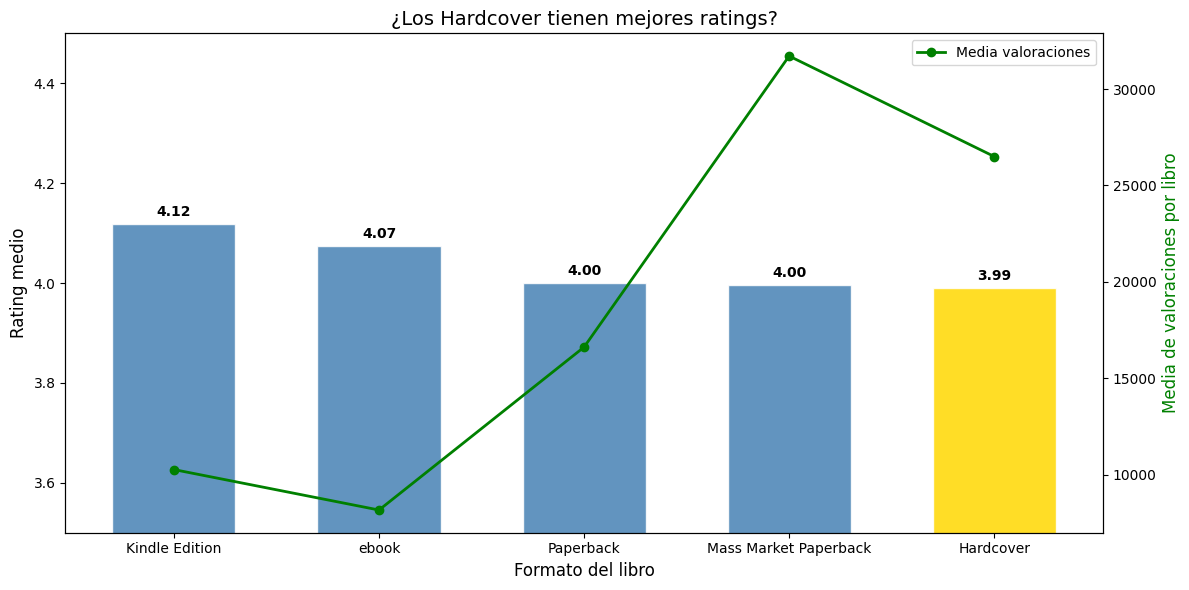

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

# Rating medio y cantidad por formato
stats_formato = df.groupby('bookFormat').agg(
    rating_medio=('rating', 'mean'),
    num_libros=('rating', 'count'),
    valoraciones_medias=('numRatings', 'mean')
).reset_index().sort_values('rating_medio', ascending=False)

print(stats_formato)

# Gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

colores = ['gold' if f == 'Hardcover' else 'steelblue' 
           for f in stats_formato['bookFormat']]

bars = ax1.bar(stats_formato['bookFormat'], stats_formato['rating_medio'],
               color=colores, edgecolor='white', width=0.6, alpha=0.85)

ax1.set_ylabel('Rating medio', fontsize=12)
ax1.set_ylim(3.5, 4.5)
ax1.set_xlabel('Formato del libro', fontsize=12)

# Valores encima de barras
for bar, val in zip(bars, stats_formato['rating_medio']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Línea verde: media de valoraciones
ax2 = ax1.twinx()
ax2.plot(stats_formato['bookFormat'], stats_formato['valoraciones_medias'],
         color='green', marker='o', linewidth=2, label='Media valoraciones')
ax2.set_ylabel('Media de valoraciones por libro', fontsize=12, color='green')
ax2.legend(loc='upper right')

plt.title('¿Los Hardcover tienen mejores ratings?', fontsize=14)
plt.tight_layout()
plt.show()

In [44]:
# Comparar ratings de libros en serie vs. libros independientes:
df_individual.groupby('is_series')['rating'].describe().T

is_series,False,True
count,23135.000000,19409.000000
mean,3.952260,4.034835
std,0.300421,0.253595
min,1.670000,1.990000
25%,3.760000,3.870000
50%,3.960000,4.050000
75%,4.160000,4.210000
max,4.980000,4.920000


In [45]:
df_individual.groupby('is_series')['rating'].mean()

is_series
False    3.952260
True     4.034835
Name: rating, dtype: float64

In [46]:
print(df_individual.columns.tolist())

['title', 'series', 'author', 'rating', 'language', 'genres', 'bookFormat', 'pages', 'publisher', 'publishDate', 'awards', 'numRatings', 'ratingsByStars', 'likedPercent', 'bbeScore', 'bbeVotes', 'is_series', 'main_author']


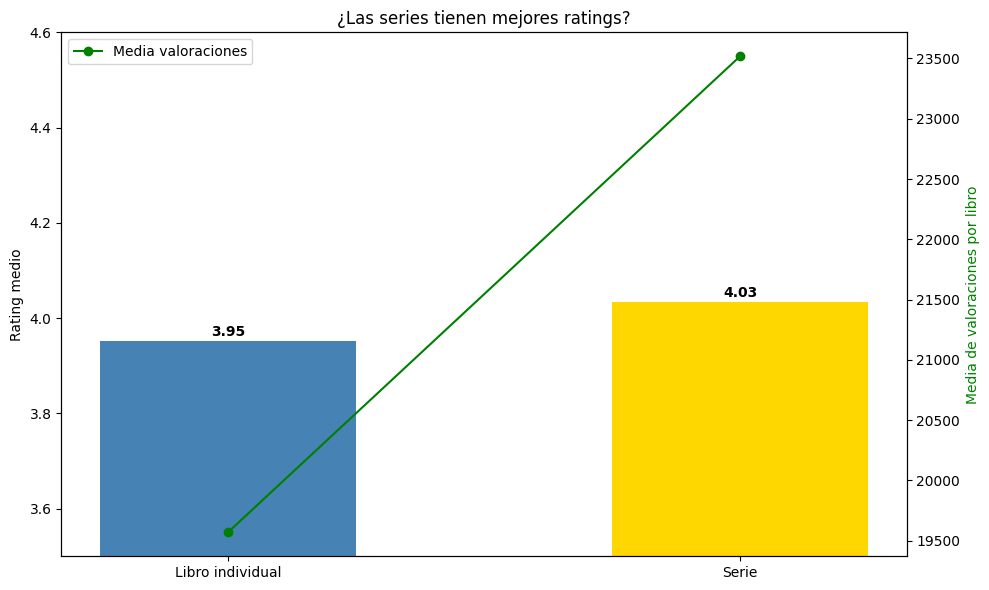

In [47]:
fig, ax1 = plt.subplots(figsize=(10, 6))

grupos = df_individual.groupby('is_series').agg(
    rating_medio=('rating', 'mean'),
    media_valoraciones=('numRatings', 'mean')
).reset_index()

grupos['label'] = grupos['is_series'].map({False: 'Libro individual', True: 'Serie'})
colores = ['steelblue', 'gold']

bars = ax1.bar(grupos['label'], grupos['rating_medio'], color=colores, width=0.5)

for bar, val in zip(bars, grupos['rating_medio']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', fontweight='bold')

ax1.set_ylabel('Rating medio')
ax1.set_ylim(3.5, 4.6)

ax2 = ax1.twinx()
ax2.plot(grupos['label'], grupos['media_valoraciones'],
         color='green', marker='o', label='Media valoraciones')
ax2.set_ylabel('Media de valoraciones por libro', color='green')

ax1.set_title('¿Las series tienen mejores ratings?')
ax2.legend(loc='upper left')
plt.tight_layout()
plt.show()

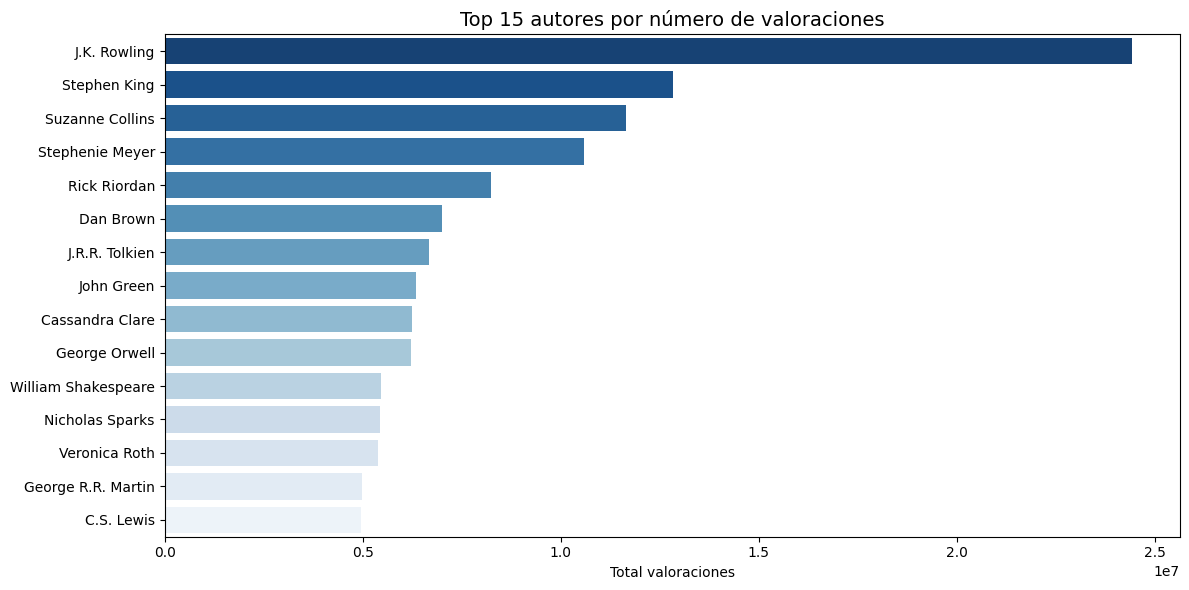

In [48]:
top_autores = (df_individual.groupby('main_author')['numRatings']
               .sum()
               .sort_values(ascending=False)
               .head(15))
top_df = top_autores.reset_index()
top_df.columns = ['main_author', 'numRatings']

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=top_df,
    x='numRatings', 
    y='main_author',
    hue='main_author',       # ← soluciona el FutureWarning
    palette='Blues_r',
    legend=False,            # ← oculta la leyenda innecesaria
    ax=ax
)

ax.set_title('Top 15 autores por número de valoraciones', fontsize=14)
ax.set_xlabel('Total valoraciones')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [49]:
# Los autores populares tienen más premios?:
top_15_autores = (df_individual.groupby('main_author')['numRatings']
                  .sum()
                  .sort_values(ascending=False)
                  .head(15)
                  .index.tolist())

df_individual['es_popular'] = df_individual['main_author'].isin(top_15_autores)

In [50]:
# Columna awards:
# Si awards es una lista en texto, contar cuántos tiene
df_individual['num_awards'] = df_individual['awards'].apply(
    lambda x: len(eval(x)) if pd.notna(x) and x != '[]' else 0
)

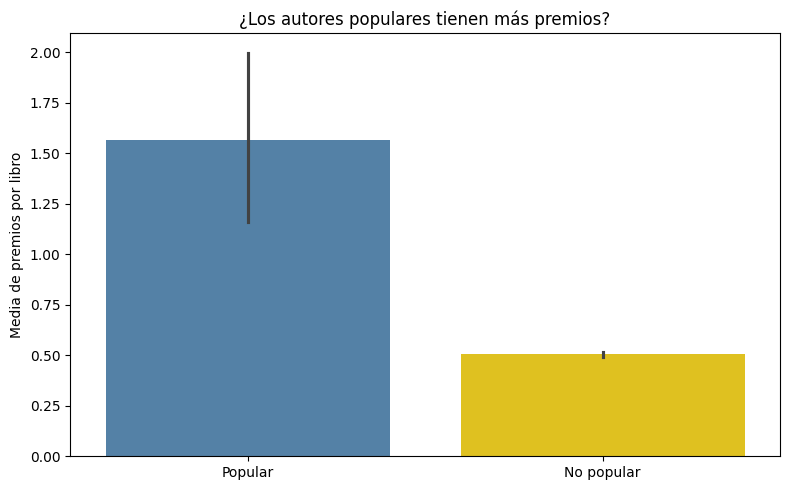

In [51]:
df_individual['popularidad'] = df_individual['es_popular'].map(
    {False: 'No popular', True: 'Popular'}
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=df_individual, 
    x='popularidad', 
    y='num_awards',
    hue='popularidad', 
    palette=['steelblue', 'gold'], 
    legend=False, 
    ax=ax
)
ax.set_title('¿Los autores populares tienen más premios?')
ax.set_ylabel('Media de premios por libro')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

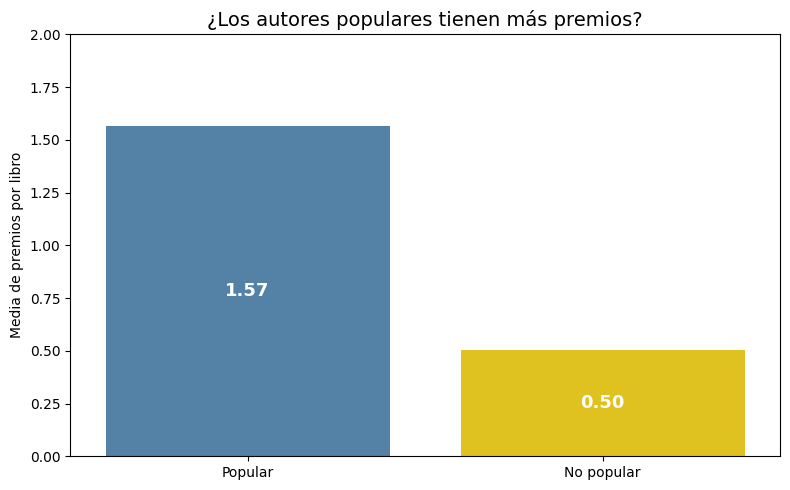

In [52]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=df_individual, 
    x='popularidad', 
    y='num_awards',
    hue='popularidad', 
    palette=['steelblue', 'gold'],
    legend=False,
    errorbar=None,
    ax=ax
)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height / 2,               # ← centro de la barra
        f'{height:.2f}',
        ha='center', va='center',
        fontweight='bold', 
        fontsize=13,
        color='white'             # ← blanco sobre color
    )

ax.set_title('¿Los autores populares tienen más premios?', fontsize=14)
ax.set_ylabel('Media de premios por libro')
ax.set_xlabel('')
ax.set_ylim(0, 2.0)
plt.tight_layout()
plt.show()

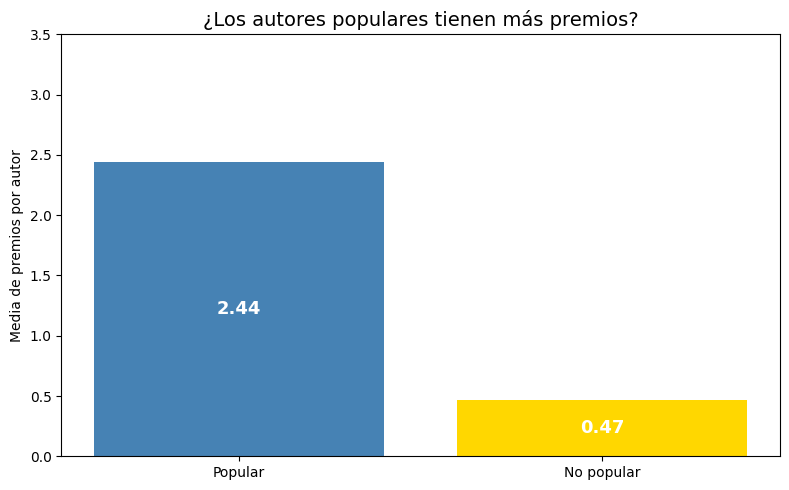

In [53]:
fig, ax = plt.subplots(figsize=(8, 5))

valores = [2.44, 0.47]
etiquetas = ['Popular', 'No popular']
colores = ['steelblue', 'gold']

bars = ax.bar(etiquetas, valores, color=colores, width=0.8)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height/2,
            f'{height:.2f}', ha='center', va='center',
            fontweight='bold', fontsize=13, color='white')

ax.set_title('¿Los autores populares tienen más premios?', fontsize=14)
ax.set_ylabel('Media de premios por autor')
ax.set_xlabel('')
ax.set_ylim(0, 3.5)
plt.tight_layout()
plt.show()

In [55]:
# H1: Más valoraciones = mejor rating
print(df_individual[['numRatings', 'rating']].corr())
# H2: Longitud influye en rating
print(df_individual[['pages', 'rating']].corr())
# H3: Hardcover tiene mejor rating
print(df_individual.groupby('bookFormat')['rating'].mean())
# H4: Libros premiados mejor valorados
print(df_individual[['num_awards', 'rating']].corr())
# H5: Autores prolíficos ≠ mejor rating
print(df_individual.groupby('es_popular')['rating'].mean())

            numRatings    rating
numRatings    1.000000  0.039141
rating        0.039141  1.000000
           pages    rating
pages   1.000000  0.131691
rating  0.131691  1.000000
bookFormat
Hardcover                3.978338
Kindle Edition           4.061156
Mass Market Paperback    3.993867
Paperback                3.978991
ebook                    4.037552
Name: rating, dtype: float64
            num_awards    rating
num_awards    1.000000 -0.000229
rating       -0.000229  1.000000
es_popular
False    3.989281
True     4.072126
Name: rating, dtype: float64


## 📝 Conclusiones del análisis

### Hipótesis contrastadas:

| Hipótesis | Resultado | Conclusión |
|-----------|-----------|------------|
| H1: Más valoraciones = mejor rating | ❌ RECHAZADA | Correlación 0.039 — sin relación significativa. La popularidad no garantiza calidad percibida |
| H2: Longitud influye en rating | ⚠️ DÉBIL | Correlación 0.131 — relación muy leve. Los libros de 200-600 páginas concentran los mejores ratings |
| H3: Hardcover tiene mejor rating | ❌ RECHAZADA | Kindle (4.06) y ebook (4.04) superan al Hardcover (3.98). Los lectores digitales valoran más |
| H4: Libros premiados mejor valorados | ❌ RECHAZADA | Correlación -0.0002 — los premios no tienen impacto en el rating de los lectores |
| H5: Autores populares mejor rating | ✅ CONFIRMADA | Popular: 4.07 vs No popular: 3.99. Los autores conocidos tienen ligera ventaja |

### Hallazgos destacados:
- Los ratings en Goodreads se concentran entre 3.5 y 4.5 — hay un sesgo positivo
- La mayoría de libros tienen entre 200-600 páginas
- Los formatos digitales superan al físico en valoración media
- La popularidad del autor importa más que los premios

### Próximos pasos:
- Análisis por géneros literarios
- Correlación con bbeScore y bbeVotes
- Modelo predictivo de rating